1. Configuração do ambiente e funções de transformações

### Descrição:
Esta seção inicial isola as configurações globais do projeto seguindo o princípio de *Single Source of Truth* (Fonte Única da Verdade), garante a criação física dos diretórios necessários e importa as bibliotecas de manipulação de dados, banco de dados e visualização gráfica.

Logo em seguida, define-se a função principal de transformação (`transformar_dados`), responsável por aplicar regras estritas de *Data Quality*, limpeza de strings para `snake_case`, remoção de resíduos textuais de índices, tratamento do formato de datas (removendo anomalias de fuso horário), padronização financeira e enriquecimento geográfico em português (PT-BR).

In [1]:
import os
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

# Configurações de exibição do Pandas (Visualização Limpa - Poluição Zero)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configurações estéticas de gráficos de alta definição (Retina)
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Configurações globais de caminhos (Single Source of Truth)
CONFIG = {
    "CAMINHO_CSV": "data/Space_Corrected.csv",
    "CAMINHO_DB": "database/Space_Corrected.db",
    "TABELA_ALVO": "missoes"
}

# Garantia física de diretórios no sistema
os.makedirs("data", exist_ok=True)
os.makedirs("database", exist_ok=True)

print("Infraestrutura de diretórios e pacotes gráficos carregados com sucesso.")

Infraestrutura de diretórios e pacotes gráficos carregados com sucesso.


In [2]:
def transformar_dados(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica regras estritas de Data Quality, tradução, tratamento de nulos,
    correção de encoding, enriquecimento geográfico e separação detalhada
    do modelo do foguete e da carga útil/missão.
    """
    df_clean = df_raw.copy()
    
    # 1. Padronização estrutural automática para snake_case minúsculo
    df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    
    # 2. Eliminação de resíduos textuais e índices fantasmas
    colunas_para_remover = ["unnamed:_0", "unnamed:_0.1", "unnamed:0", "unnamed:_0_int64", "unnamed: 0"]
    df_clean = df_clean.drop(columns=[c for c in colunas_para_remover if c in df_clean.columns], errors="ignore")
    
    if df_clean.iloc[:, 0].dtype in [np.int64, np.int32] and df_clean.iloc[0, 0] == 0:
        df_clean = df_clean.drop(df_clean.columns[0], axis=1)
    
    # 3. Mapeamento e Tradução de Cabeçalhos
    mapeamento_colunas = {
        "company_name": "empresa", 
        "rocket": "custo_foguete",
        "status_rocket": "status_foguete",
        "rocket_status": "status_foguete",
        "status_mission": "status_missao",
        "mission_status": "status_missao",
        "detail": "detalhes"
    }
    df_clean = df_clean.rename(columns=mapeamento_colunas)
    
    # 4. DECOMPOSIÇÃO DETALHADA (Modelo do Foguete vs Missão e Protótipo)
    if "detalhes" in df_clean.columns:
        df_clean["modelo_foguete"] = df_clean["detalhes"].apply(
            lambda x: str(x).split("|")[0].strip() if "|" in str(x) else str(x).strip()
        )
        df_clean["missao_carga_util"] = df_clean["detalhes"].apply(
            lambda x: str(x).split("|")[1].strip() if "|" in str(x) else "Não Especificada"
        )
        
        df_clean["prototipo"] = df_clean["modelo_foguete"].str.contains("Prototype|Test", case=False, na=False)
        df_clean["prototipo"] = df_clean["prototipo"].map({True: "Sim", False: "Não"})
    
    # 5. Enriquecimento Geográfico Vetorizado
    if "location" in df_clean.columns:
        df_clean["pais"] = df_clean["location"].str.split(",").str[-1].str.strip()
        df_clean["estado_regiao"] = df_clean["location"].str.split(",").str[-2].str.strip()
        df_clean["base_lancamento"] = df_clean["location"].str.split(",").str[0].str.strip()
        df_clean = df_clean.drop(columns=["location"])
    
    # 6. DICIONÁRIO DE TRADUÇÃO GEOPOLÍTICA (Atualizado com Irã, Japão, Cazaquistão, etc.)
    dicionario_paises = {
        "France": "França", 
        "New Mexico": "USA", 
        "Yellow Sea": "China", 
        "Shahrud Missile Test Site": "Iran", 
        "Russian Federation": "Rússia",
        "USSR": "Rússia", 
        "Brazil": "Brasil",
        "Iran": "Irã",
        "Japan": "Japão",
        "Kazakhstan": "Cazaquistão",
        "Pacific Ocean": "Oceano Pacífico",
        "Ocean Pacific": "Oceano Pacífico",
        "Barents Sea": "Mar de Barents",
        "Gran Canaria": "Gran Canária"
    }
    if "pais" in df_clean.columns:
        df_clean["pais"] = df_clean["pais"].replace(dicionario_paises)
    
    # 7. Correção de Encoding e Tradução de Bases/Regiões (PT-BR)
    if "estado_regiao" in df_clean.columns:
        df_clean["estado_regiao"] = df_clean["estado_regiao"].str.replace(r"Maranh.*", "Maranhão", regex=True)
        df_clean["estado_regiao"] = df_clean["estado_regiao"].str.replace(r"M.*hia.*Peninsula", "Península de Mahia", regex=True)
        df_clean["estado_regiao"] = df_clean["estado_regiao"].replace({"French Guiana": "Guiana Francesa"})
        # Aplica o mesmo dicionário nas regiões caso esses nomes apareçam nessa coluna
        df_clean["estado_regiao"] = df_clean["estado_regiao"].replace(dicionario_paises)
    
    if "base_lancamento" in df_clean.columns:
        df_clean["base_lancamento"] = (df_clean["base_lancamento"]
                                       .str.replace("Launch Center", "Centro de Lançamento", case=False, regex=False)
                                       .str.replace("Launch Complex", "Complexo de Lançamento", case=False, regex=False)
                                       .str.replace("Launch Site", "Sítio de Lançamento", case=False, regex=False)
                                       .str.replace("Spaceport", "Porto Espacial", case=False, regex=False))
        
        mascara_alcantara = df_clean["base_lancamento"].str.contains("Alcântara|Alcantara", case=False, na=False)
        df_clean.loc[mascara_alcantara, "base_lancamento"] = "Centro Espacial de Alcântara"
        mascara_guiana = df_clean["base_lancamento"].str.contains("Guiana Space Centre|Kourou", case=False, na=False)
        df_clean.loc[mascara_guiana, "base_lancamento"] = "Centro Espacial da Guiana"
    
    # 8. Tratamento Temporal Estrito
    if "datum" in df_clean.columns:
        df_clean["datum_limpo"] = df_clean["datum"].str.replace(r"\s+UTC.*$", "", regex=True).str.strip()
        df_clean["data_convertida"] = pd.to_datetime(df_clean["datum_limpo"], format="%a %b %d, %Y %H:%M", errors="coerce")
        
        mascara_nat = df_clean["data_convertida"].isna()
        df_clean.loc[mascara_nat, "data_convertida"] = pd.to_datetime(df_clean.loc[mascara_nat, "datum_limpo"], format="%a %b %d, %Y", errors="coerce")
        
        df_clean["data_lancamento"] = df_clean["data_convertida"].dt.strftime("%Y-%m-%d")
        df_clean["hora_lancamento"] = df_clean["data_convertida"].dt.strftime("%H:%M")
        df_clean["hora_lancamento"] = df_clean["hora_lancamento"].fillna("Não Informada")
        df_clean = df_clean.drop(columns=["datum", "datum_limpo", "data_convertida"])
        
    # 9. Tipagem Numérica Financeira
    if "custo_foguete" in df_clean.columns:
        df_clean["custo_foguete"] = df_clean["custo_foguete"].astype(str).str.replace(",", "", regex=False).str.strip()
        df_clean["custo_foguete"] = pd.to_numeric(df_clean["custo_foguete"], errors="coerce")
        
    # 10. Mapeamento Semântico de Negócio
    dicionario_status = {"StatusActive": "Ativo", "StatusRetired": "Aposentado"}
    dicionario_missao = {"Success": "Sucesso", "Failure": "Falha", "Partial Failure": "Falha Parcial", "Prelaunch Failure": "Falha no Pré-lançamento"}
    
    if "status_foguete" in df_clean.columns:
        df_clean["status_foguete"] = df_clean["status_foguete"].map(dicionario_status).fillna(df_clean["status_foguete"])
    else:
        df_clean["status_foguete"] = "Não Informado"
        
    if "status_missao" in df_clean.columns:
        df_clean["status_missao"] = df_clean["status_missao"].map(dicionario_missao).fillna(df_clean["status_missao"])
    else:
        df_clean["status_missao"] = "Não Informado"
    
    return df_clean

2. Execução do Pipeline ETL, Perfilamento e Persistência no SQLite

### Descrição:

Nesta etapa, o script implementa uma validação de erro para impedir a execução caso o arquivo CSV de origem esteja ausente. Após a leitura e execução de todas as regras de limpeza estruturadas no passo anterior, é gerado um relatório de qualidade descritivo (Data Profiling) exibindo os tipos físicos finais das colunas e a quantidade/porcentagem de dados nulos restantes.

Após a validação, os dados limpos são injetados de forma idempotente (substituindo estruturas antigas com o argumento if_exists="replace") dentro de um banco de dados relacional local (SQLite).

In [3]:
# Validação Fail-Fast (Proteção contra arquivo ausente)
if not os.path.exists(CONFIG["CAMINHO_CSV"]):
    raise FileNotFoundError(f"Erro Crítico: O arquivo '{CONFIG['CAMINHO_CSV']}' não foi localizado na pasta 'data/'.")

# 1. Carga Primária e Transformação Total
df_raw = pd.read_csv(CONFIG["CAMINHO_CSV"])
df_clean = transformar_dados(df_raw)

# 2. Relatório Detalhado de Qualidade (Profiling Automatizado)
print("--- Dtypes Físicos de Destino ---")
df_types = df_clean.dtypes.to_frame(name="Tipo de Dado").reset_index().rename(columns={"index": "Atributo"})
display(HTML(df_types.to_html(index=False)))

print("\n--- Métricas de Campos Nulos/Ausentes ---")
df_missing = pd.DataFrame({
    "Nulos (Absoluto)": df_clean.isna().sum(), 
    "Nulos (%)": (df_clean.isna().sum() / len(df_clean) * 100)
}).reset_index().rename(columns={"index": "Atributo"})
display(HTML(df_missing.to_html(index=False)))
print(f"\nShape Final Otimizado: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas")

# 3. Persistência Relacional com Idempotência Absoluta
with sqlite3.connect(CONFIG["CAMINHO_DB"]) as conn:
    df_clean.to_sql(CONFIG["TABELA_ALVO"], conn, if_exists="replace", index=False)
    
print("\n[SUCESSO] Tabela SQLite criada e populada com sucesso.")

--- Dtypes Físicos de Destino ---


Atributo,Tipo de Dado
empresa,str
detalhes,str
status_foguete,str
custo_foguete,float64
status_missao,str
modelo_foguete,str
missao_carga_util,str
prototipo,str
pais,object
estado_regiao,object



--- Métricas de Campos Nulos/Ausentes ---


Atributo,Nulos (Absoluto),Nulos (%)
empresa,0,0.00
detalhes,0,0.00
status_foguete,0,0.00
custo_foguete,3360,77.71
status_missao,0,0.00
modelo_foguete,0,0.00
missao_carga_util,0,0.00
prototipo,0,0.00
pais,0,0.00
estado_regiao,0,0.00



Shape Final Otimizado: 4324 linhas x 13 colunas

[SUCESSO] Tabela SQLite criada e populada com sucesso.


3. Testes Estruturais e Auditoria de Dados SQL

### Descrição
Esta seção executa testes diretos na base relacional criada (SQLite) usando consultas puras de SQL encapsuladas pela função de conveniência executar_sql_query.

Os testes auditam três aspectos: o Schema interno do banco via meta-comando PRAGMA, a higienização textual e consolidação das variáveis categóricas de status (status_foguete e status_missao), e o comportamento geográfico gerado pelo processo de padronização, exibindo os 5 países com maior presença de lançamentos no repositório histórico.

In [4]:
def executar_sql_query(query: str) -> pd.DataFrame:
    """Executa consultas de teste estruturais na base SQLite criada."""
    with sqlite3.connect(CONFIG["CAMINHO_DB"]) as conn:
        return pd.read_sql_query(query, conn)

print("TESTE 1: Validando Schema Físico Interno do SQLite:")
display(HTML(executar_sql_query(f"PRAGMA table_info({CONFIG['TABELA_ALVO']});").to_html(index=False)))

print("\nTESTE 2: Validando Higienização de Categorias (Amostra):")
display(HTML(executar_sql_query(f"SELECT DISTINCT status_foguete, status_missao FROM {CONFIG['TABELA_ALVO']} LIMIT 5;").to_html(index=False)))

print("\nTESTE 3: Validando Enriquecimento Geográfico (Top 5 Países):")
display(HTML(executar_sql_query(f"SELECT pais, COUNT(*) as total FROM {CONFIG['TABELA_ALVO']} GROUP BY pais ORDER BY total DESC LIMIT 5;").to_html(index=False)))

# Leitura Segura Desacoplada para a Camada Analítica (EDA)
with sqlite3.connect(CONFIG["CAMINHO_DB"]) as conexao:
    df_analitico = pd.read_sql(f"SELECT * FROM {CONFIG['TABELA_ALVO']}", conexao)

# Otimização de dtypes categoriais (Coluna alterada para 'prototipo')
colunas_categoriais = ["status_foguete", "status_missao", "base_lancamento", "estado_regiao", "pais", "prototipo"]
for col in colunas_categoriais:
    if col in df_analitico.columns:
        df_analitico[col] = df_analitico[col].astype("category")

TESTE 1: Validando Schema Físico Interno do SQLite:


cid,name,type,notnull,dflt_value,pk
0,empresa,TEXT,0,None,0
1,detalhes,TEXT,0,None,0
2,status_foguete,TEXT,0,None,0
3,custo_foguete,REAL,0,None,0
4,status_missao,TEXT,0,None,0
5,modelo_foguete,TEXT,0,None,0
6,missao_carga_util,TEXT,0,None,0
7,prototipo,TEXT,0,None,0
8,pais,TEXT,0,None,0
9,estado_regiao,TEXT,0,None,0



TESTE 2: Validando Higienização de Categorias (Amostra):


status_foguete,status_missao
Ativo,Sucesso
Ativo,Falha
Aposentado,Sucesso
Ativo,Falha no Pré-lançamento
Ativo,Falha Parcial



TESTE 3: Validando Enriquecimento Geográfico (Top 5 Países):


pais,total
Russia,1395
USA,1348
Cazaquistão,701
França,303
China,269


4. Análise Exploratória: Distribuição de Desfechos (Status das Missões)
### Descrição

Início da camada analítica (EDA). Os dados são extraídos da base relacional de forma totalmente desacoplada das etapas anteriores. O tipo de dado das colunas qualitativas de alta cardinalidade é convertido explicitamente para category visando a otimização de memória do ambiente.

Abaixo, calcula-se o total absoluto e relativo do resultado de todas as operações espaciais globais registradas, plotando um gráfico de barras categórico para avaliar a taxa histórica de falhas gerais do setor aeroespacial.

Total de Missões Catalogadas: 4324

Distribuição e Proporção do Status das Missões:


,Total Absoluto,Percentual (%)
status_missao,,
Sucesso,3879,89.71
Falha,339,7.84
Falha Parcial,102,2.36
Falha no Pré-lançamento,4,0.09


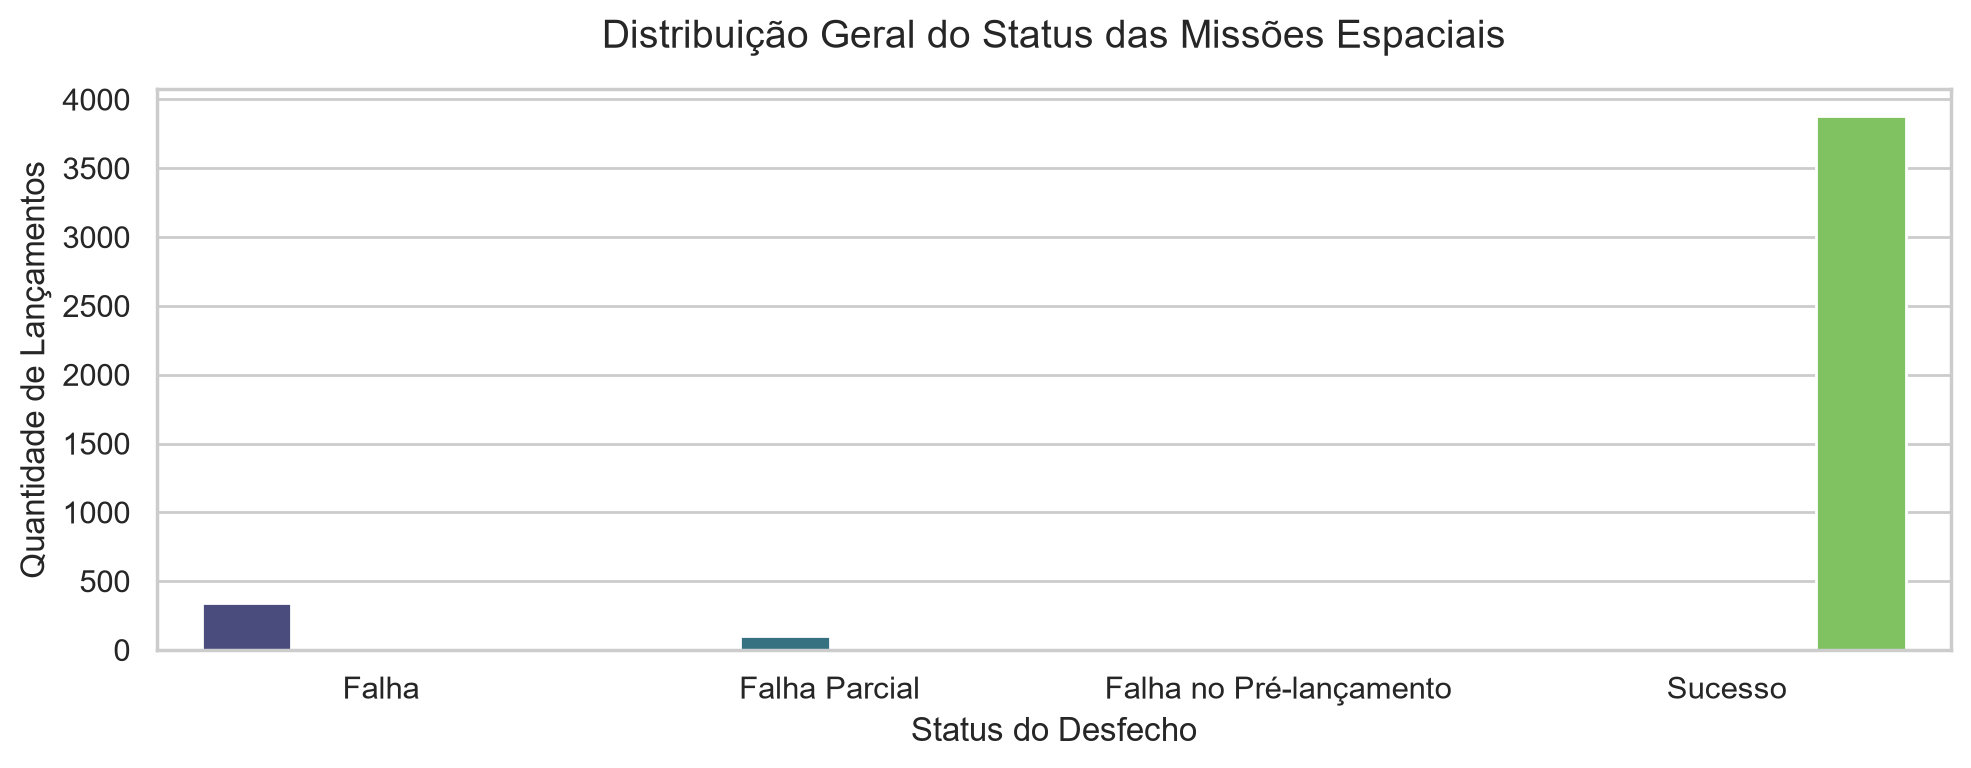

In [5]:
total_missoes = len(df_analitico)
print(f"Total de Missões Catalogadas: {total_missoes}\n")

# Agrupamento sem poluição visual
contagem_status = df_analitico["status_missao"].value_counts()
df_status_report = pd.DataFrame({
    "Total Absoluto": contagem_status,
    "Percentual (%)": (contagem_status / total_missoes * 100)
})

print("Distribuição e Proporção do Status das Missões:")
display(df_status_report)

# Plotagem Gráfica
plt.figure(figsize=(10, 4))
sns.barplot(
    x=df_status_report.index, 
    y="Total Absoluto", 
    data=df_status_report, 
    hue=df_status_report.index, 
    legend=False, 
    palette="viridis"
)
plt.title("Distribuição Geral do Status das Missões Espaciais", fontsize=14, pad=15)
plt.ylabel("Quantidade de Lançamentos")
plt.xlabel("Status do Desfecho")
plt.tight_layout()
plt.show()

5. Análise de Evolução Orçamentária e Eficiência Corporativa

### Descrição
Esta seção fecha a análise com duas frentes complexas:

Histórico Financeiro Anual: Aplica filtros temporais descartando registros sem informações orçamentárias explícitas, agrupando os custos totais acumulados e a média de custo por foguete por ano, plotando em seguida um gráfico de linhas de tendência evolutiva.

Ranking Corporativo: Extrai a Taxa de Sucesso Real (%) de cada empresa. Para mitigar distorções e garantir relevância estatística, aplica-se uma cláusula de corte (query), avaliando exclusivamente corporações/agências que possuam um histórico robusto igual ou superior a 10 lançamentos efetuados.

Histórico Financeiro Aeroespacial por Ano (Amostra: 964 missões):


,missoes_com_custo_informado,custo_total_acumulado_mi_usd,custo_medio_por_foguete_mi_usd
ano,,,
2020,52,2945.81,56.65
2019,73,4351.51,59.61
2018,88,5697.98,64.75
2017,66,4586.41,69.49
2016,64,5085.27,79.46
2015,39,3570.40,91.55
2014,41,4204.60,102.55
2013,33,2988.20,90.55
2012,25,3057.30,122.29


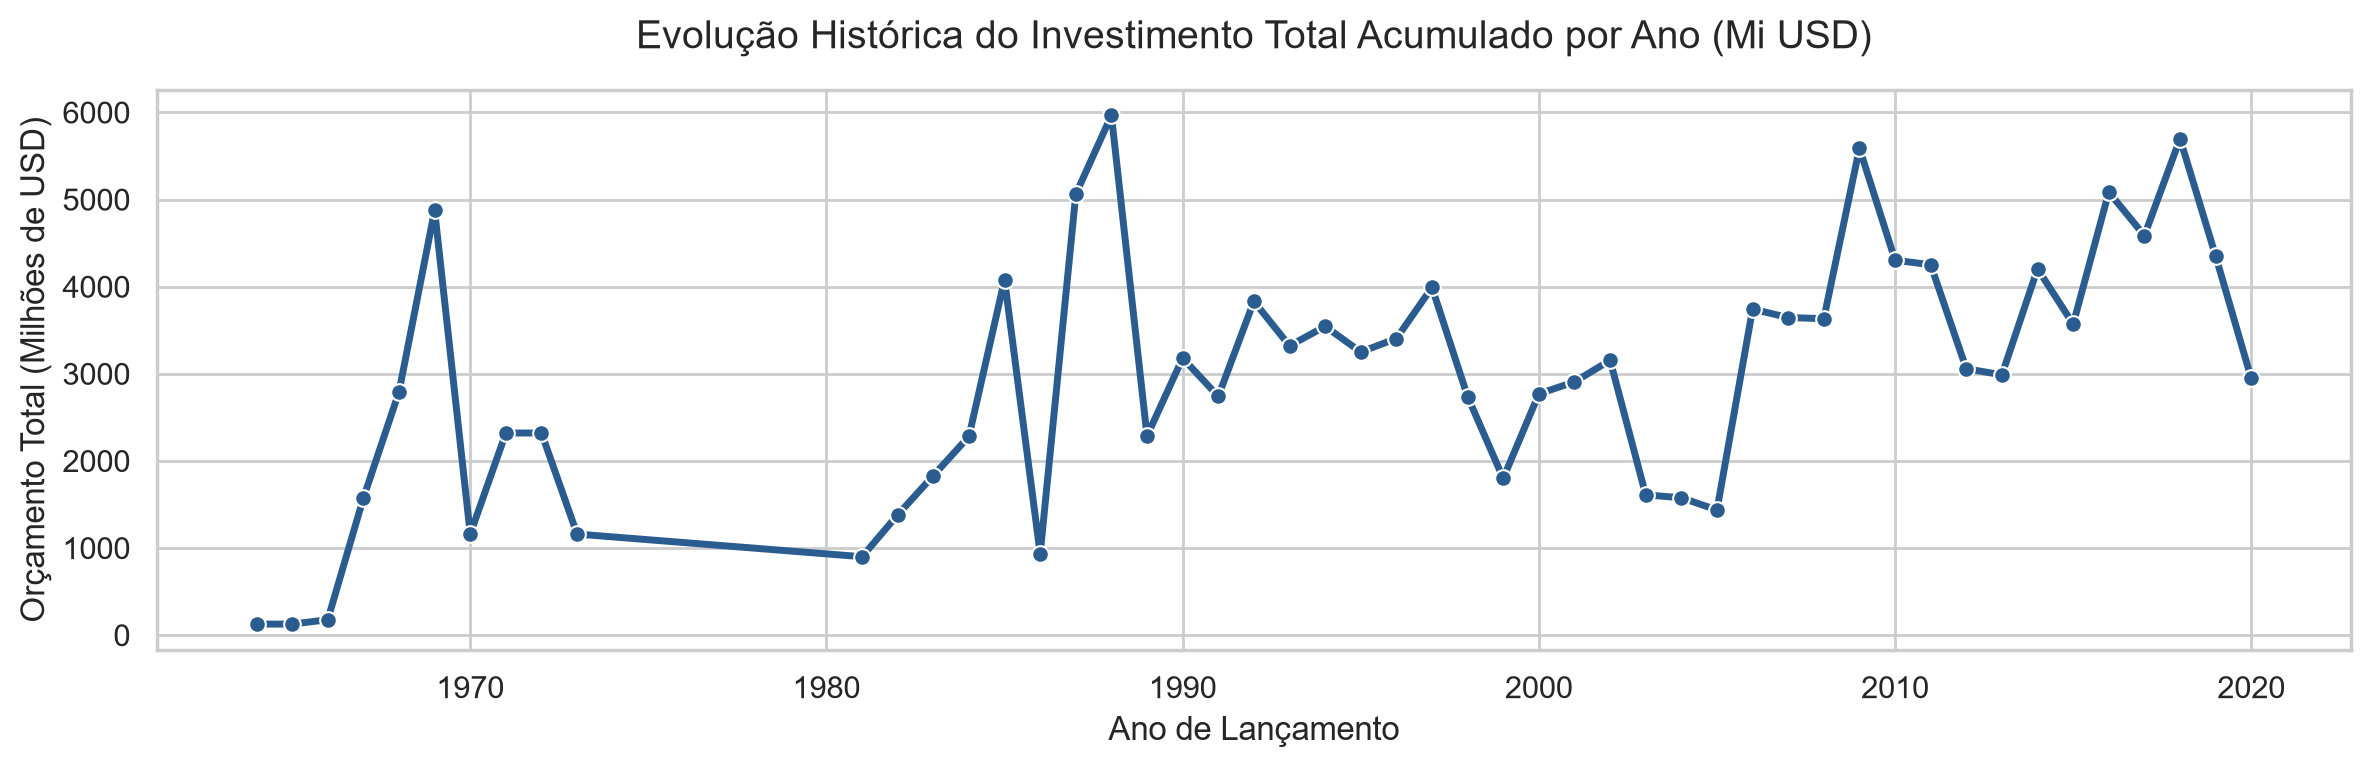


Ranking de Eficiência de Lançamentos Aeroespaciais (Mínimo de 10 operações):


empresa,total_lancamentos,lancamentos_com_sucesso,taxa_sucesso (%)
Blue Origin,12,12,100.00
ULA,140,139,99.29
ILS,46,45,97.83
Arianespace,279,269,96.42
Boeing,136,131,96.32
Kosmotras,22,21,95.45
MHI,84,80,95.24
SpaceX,100,94,94.00
Lockheed,79,74,93.67
VKS RF,201,188,93.53


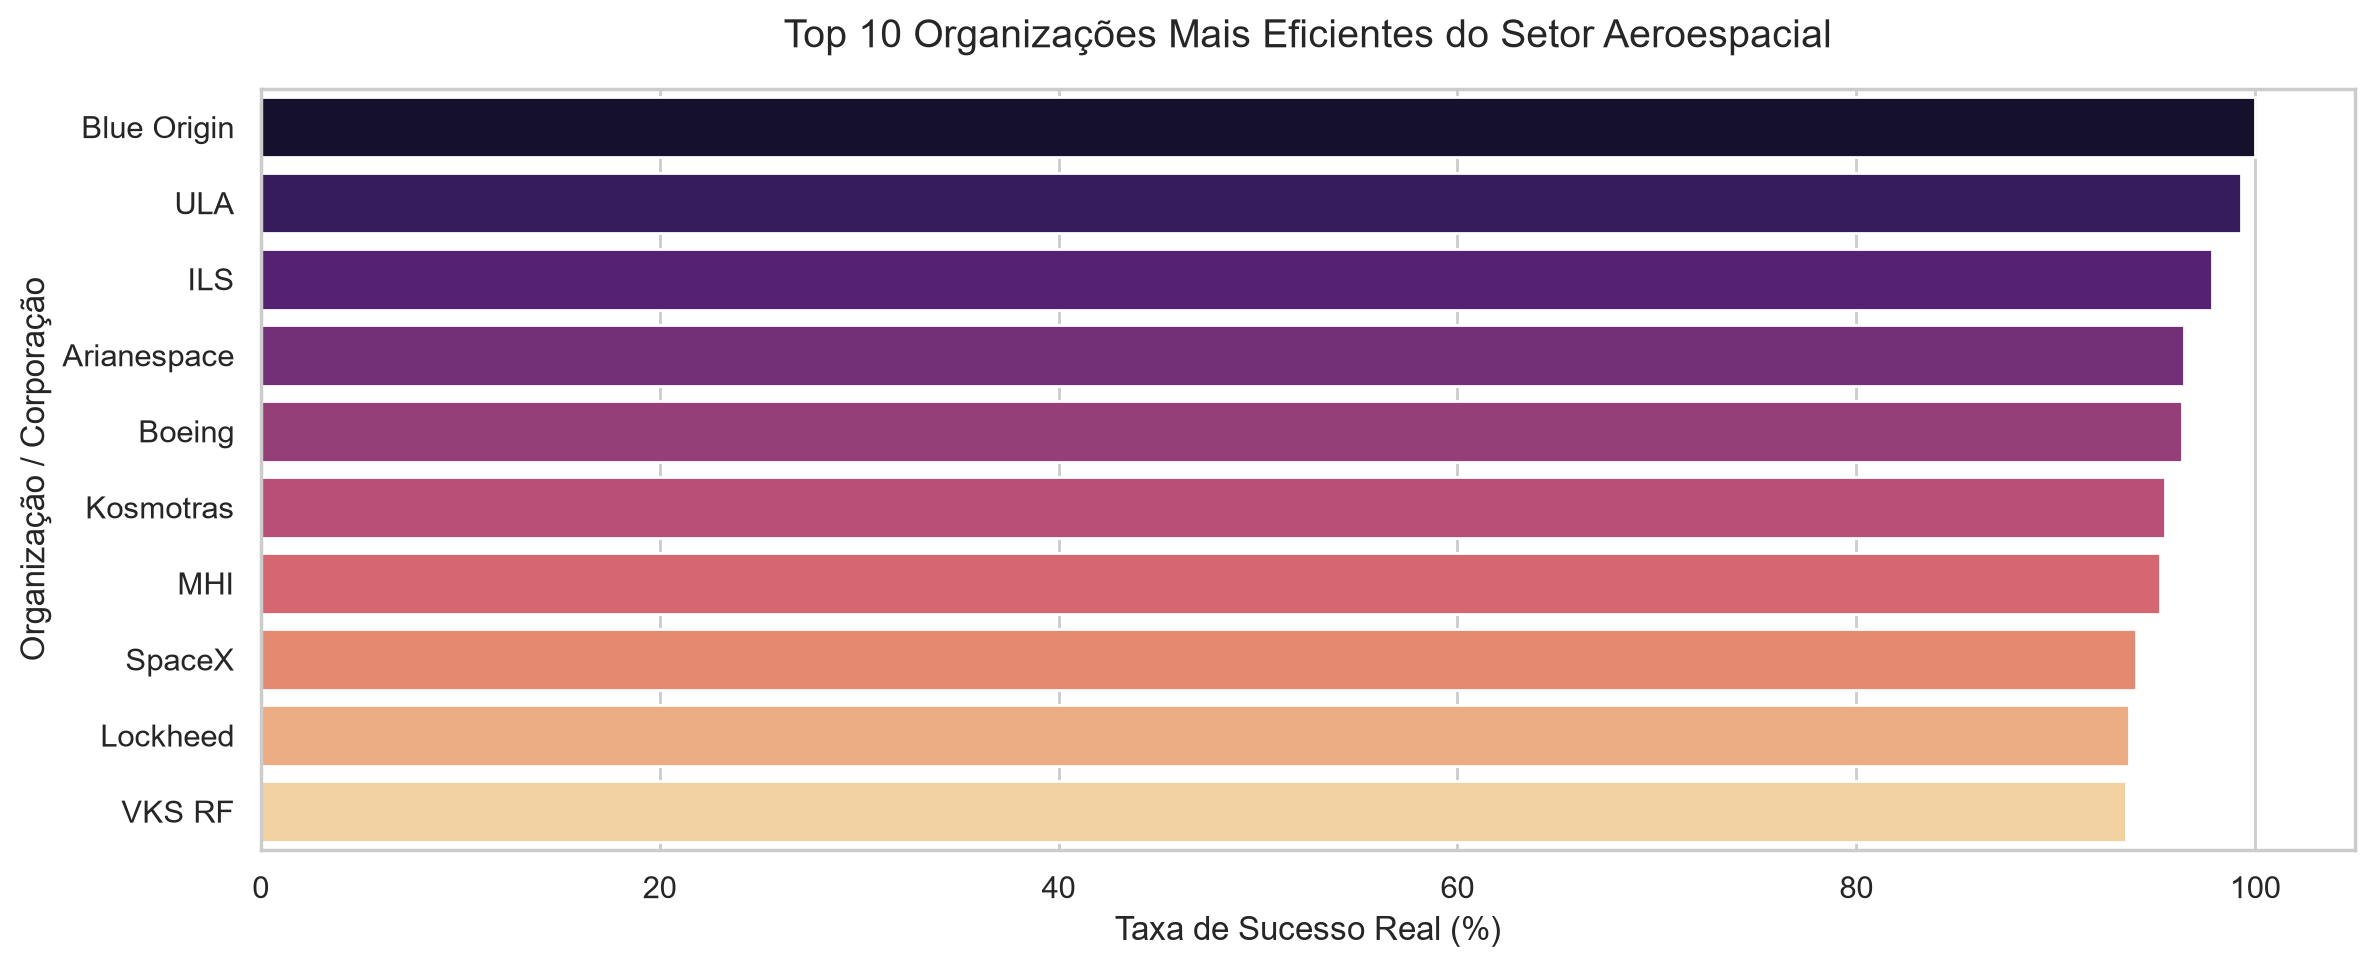

In [6]:
# 1. Tratamento Cronológico de Custos
df_analitico["data_lancamento"] = pd.to_datetime(df_analitico["data_lancamento"], errors="coerce")
df_com_investimento = df_analitico.dropna(subset=["custo_foguete", "data_lancamento"]).copy()
df_com_investimento["ano"] = df_com_investimento["data_lancamento"].dt.year

df_investimento_anual = (
    df_com_investimento
    .groupby("ano")["custo_foguete"]
    .agg(missoes_com_custo_informado="count", custo_total_acumulado_mi_usd="sum", custo_medio_por_foguete_mi_usd="mean")
    .sort_index(ascending=False)
)
    
print(f"Histórico Financeiro Aeroespacial por Ano (Amostra: {len(df_com_investimento)} missões):")
display(df_investimento_anual.head(15))

plt.figure(figsize=(12, 4))
df_plot_custo = df_investimento_anual.sort_index(ascending=True)
sns.lineplot(x=df_plot_custo.index, y="custo_total_acumulado_mi_usd", data=df_plot_custo, marker="o", color="#2b5c8f", linewidth=2.5)
plt.title("Evolução Histórica do Investimento Total Acumulado por Ano (Mi USD)", fontsize=14, pad=15)
plt.ylabel("Orçamento Total (Milhões de USD)")
plt.xlabel("Ano de Lançamento")
plt.tight_layout()
plt.show()  

# 2. Cálculo do Ranking de Eficiência Corporativa
df_analitico["is_sucesso"] = df_analitico["status_missao"] == "Sucesso"
df_perf_empresa = df_analitico.groupby("empresa", observed=False).agg(total_lancamentos=("is_sucesso", "count"), lancamentos_com_sucesso=("is_sucesso", "sum")).reset_index()
df_perf_empresa["taxa_sucesso (%)"] = (df_perf_empresa["lancamentos_com_sucesso"] / df_perf_empresa["total_lancamentos"] * 100)

ranking_corporativo = df_perf_empresa.query("total_lancamentos >= 10").sort_values(by="taxa_sucesso (%)", ascending=False).reset_index(drop=True)
    
print("\nRanking de Eficiência de Lançamentos Aeroespaciais (Mínimo de 10 operações):")
display(HTML(ranking_corporativo.to_html(index=False)))

# Geração de Gráfico de Eficiência Corporativa
plt.figure(figsize=(12, 5))
top_10_eficientes = ranking_corporativo.head(10)
sns.barplot(x="taxa_sucesso (%)", y="empresa", data=top_10_eficientes, hue="empresa", legend=False, palette="magma")
plt.title("Top 10 Organizações Mais Eficientes do Setor Aeroespacial", fontsize=14, pad=15)
plt.xlabel("Taxa de Sucesso Real (%)")
plt.ylabel("Organização / Corporação")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()